Struktur Data (Data Structure)

In [32]:
# ==========================================
# 1. IMPORT LIBRARY & SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Menghilangkan warning merah yang mengganggu

# Setup tema seaborn untuk grafik standar jurnal
sns.set_theme(style="whitegrid", palette="muted")

# LOAD DATA
# Pastikan path file sesuai dengan direktori Master
file_path = 'E:\Python - Project\phone-addiction-detection\Data\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
df = pd.read_csv(file_path)

print(f"Dataset berhasil dimuat! Dimensi data: {df.shape[0]} Baris, {df.shape[1]} Kolom")

Dataset berhasil dimuat! Dimensi data: 7500 Baris, 16 Kolom


Pre-Cleaning & Missing Values

In [33]:
# ==========================================
# 2. PRE-CLEANING & MISSING VALUES
# ==========================================
# Drop kolom ID karena tidak memiliki nilai prediktif untuk Machine Learning
kolom_drop = ['transaction_id', 'user_id']
df.drop(columns=kolom_drop, inplace=True, errors='ignore')

# Cek Missing Values
print("=== MISSING VALUES ===")
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Total Kosong': missing_data, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Total Kosong'] > 0])

# Insight & Tindakan: 
# Kolom 'addiction_level' memiliki missing value dan merupakan target leak.
# Kita drop kolom tersebut karena kita akan fokus menggunakan 'addicted_label'.
df.drop(columns=['addiction_level'], inplace=True, errors='ignore')
print("\nKolom 'addiction_level' berhasil dihapus untuk mencegah target leakage.")

=== MISSING VALUES ===
                 Total Kosong  Persentase (%)
addiction_level           819           10.92

Kolom 'addiction_level' berhasil dihapus untuk mencegah target leakage.


Visualisasi Outlier (Pencilan Data) Terpusat

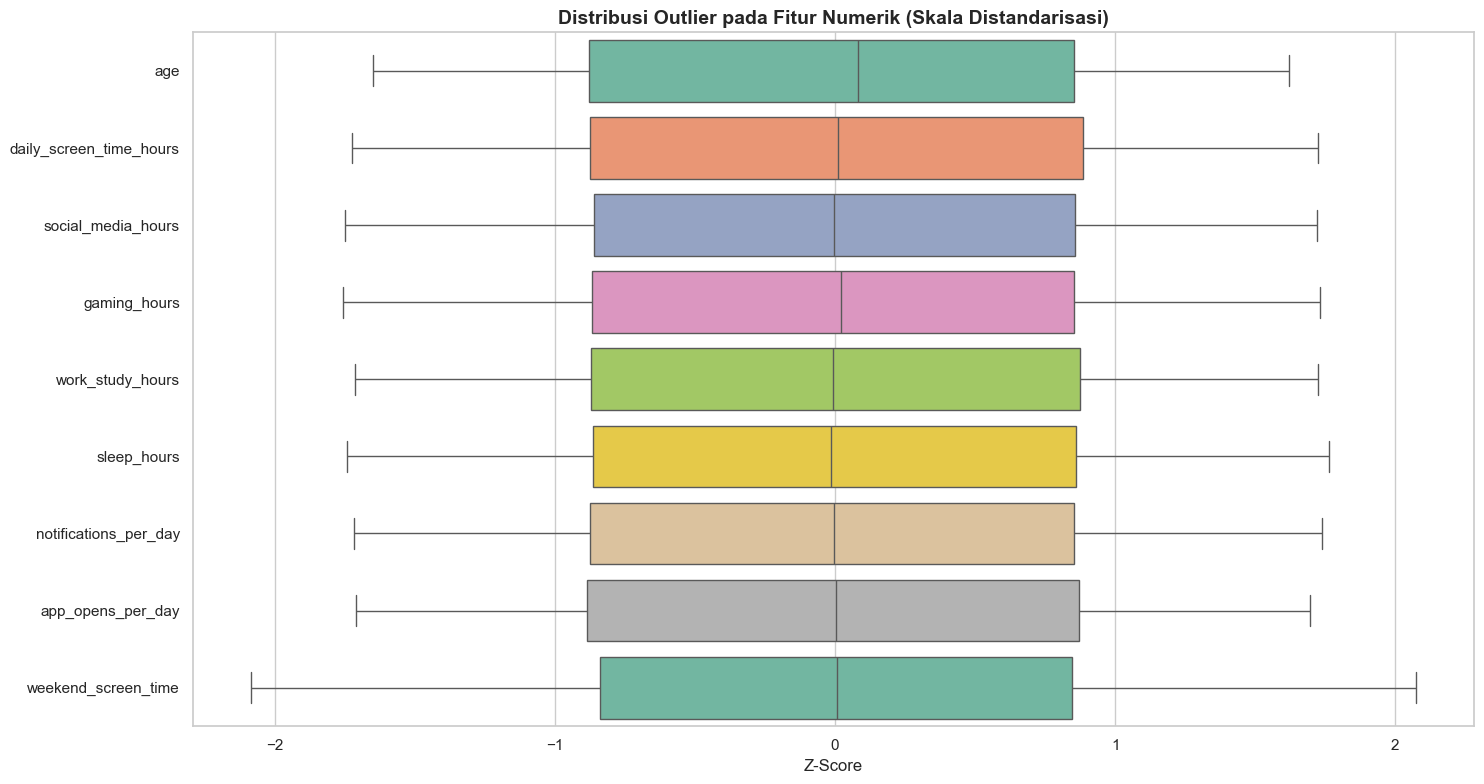

=== BUKTI MATEMATIS OUTLIER (IQR) ===
Jika tidak ada output di atas, berarti dataset Master 100% BEBAS OUTLIER.


In [34]:
# ==========================================
# 3. DETEKSI OUTLIER DENGAN VISUALISASI (BOXPLOT)
# ==========================================
# Mengambil kolom numerik saja (kecuali label target)
num_cols = df.select_dtypes(include=np.number).columns.drop('addicted_label', errors='ignore')

plt.figure(figsize=(15, 8))
# Melakukan scaling sementara (Standardization) hanya untuk visualisasi Boxplot 
# agar skala waktunya (jam) dan notifikasi (ratusan) bisa sejajar di satu grafik.
df_viz = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

sns.boxplot(data=df_viz, orient="h", palette="Set2")
plt.title("Distribusi Outlier pada Fitur Numerik (Skala Distandarisasi)", fontsize=14, fontweight='bold')
plt.xlabel("Z-Score")
plt.tight_layout()
plt.show()

# Bukti Matematis (IQR Method)
print("=== BUKTI MATEMATIS OUTLIER (IQR) ===")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    if len(outliers) > 0:
        print(f"{col}: Terdapat {len(outliers)} outlier.")
print("Jika tidak ada output di atas, berarti dataset Master 100% BEBAS OUTLIER.")

Analisis Distribusi Target (Class Imbalance)

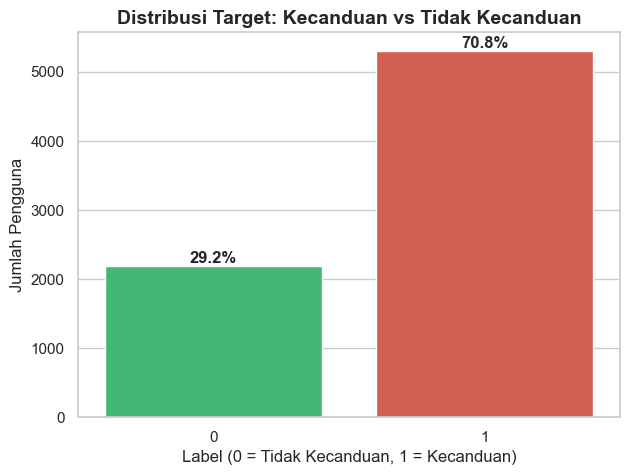

In [35]:
# ==========================================
# 4. ANALISIS KESEIMBANGAN TARGET (CLASS IMBALANCE)
# ==========================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='addicted_label', palette=['#2ecc71', '#e74c3c'])

plt.title("Distribusi Target: Kecanduan vs Tidak Kecanduan", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Tidak Kecanduan, 1 = Kecanduan)")
plt.ylabel("Jumlah Pengguna")

# Menambahkan anotasi persentase di atas bar
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

Korelasi Matrix (Heatmap)

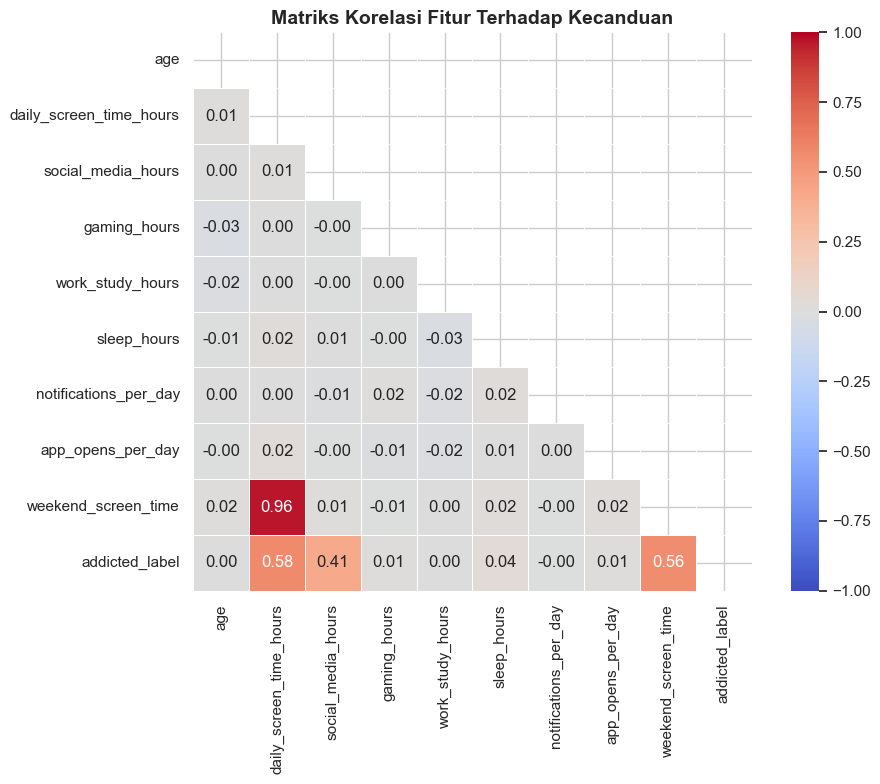

=== TOP FITUR YANG BERPENGARUH PADA KECANDUAN ===
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
Name: addicted_label, dtype: float64


In [36]:
# ==========================================
# 5. ANALISIS KORELASI FITUR (HEATMAP)
# ==========================================
plt.figure(figsize=(10, 8))

# Hitung korelasi hanya untuk tipe data numerik
korelasi = df.select_dtypes(include=np.number).corr()

# Buat mask agar heatmap berbentuk segitiga (agar tidak duplikat visual)
mask = np.triu(np.ones_like(korelasi, dtype=bool))

sns.heatmap(korelasi, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)

plt.title("Matriks Korelasi Fitur Terhadap Kecanduan", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Ekstrak fitur yang paling berkorelasi dengan target
print("=== TOP FITUR YANG BERPENGARUH PADA KECANDUAN ===")
print(korelasi['addicted_label'].sort_values(ascending=False)[1:4])